<a href="https://colab.research.google.com/github/pradeep-ramola/AI-ML/blob/main/resnet34_oxford_flowers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import shutil
import scipy.io as sio


tgz_path = "/content/102flowers.tgz"
extract_dir = "/content/flowers_dataset"

shutil.unpack_archive(tgz_path, extract_dir)

1. Model implementation:
• Build the ResNet-34 architecture following the configuration described in the
original paper: configuration 34-layer (refer to the paper, page 774)
• Use modular PyTorch code (e.g., BasicBlock, ResNet class).

In [ ]:
import os, time, copy
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import scipy.io as sio

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms


class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return self.relu(out)

class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=102):
        super().__init__()
        self.in_planes = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_planes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_planes, planes * block.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = [block(self.in_planes, planes, stride, downsample)]
        self.in_planes = planes * block.expansion
        layers += [block(self.in_planes, planes) for _ in range(1, blocks)]
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

def resnet34(num_classes=102):
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes=num_classes)


Apply your ResNet-34 model to the Flower Dataset. Perform standard
preprocessing and data augmentation (resize, normalization, etc.).

In [ ]:
import os
import random
import scipy.io as sio
from PIL import Image
import torch
from torch.utils.data import Dataset

class Oxford102Dataset(Dataset):
    def __init__(self, images_dir, img_list, labels, transform=None):
        self.images_dir = images_dir
        self.img_list = img_list
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.img_list)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.img_list[idx])
        img = Image.open(img_path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, int(self.labels[idx]) - 1

def load_oxford102_custom(images_dir_base, imagelabels, split_ratio=(0.75, 0.15, 0.10), seed=42):
    # Load labels
    labels = sio.loadmat(imagelabels)["labels"][0]
    images_dir = os.path.join(images_dir_base, "jpg") # Construct the full path here
    all_imgs = sorted(os.listdir(images_dir))

    # Ensure alignment
    assert len(all_imgs) == len(labels), "Mismatch between images and labels!"

    # Shuffle indices
    random.seed(seed)
    indices = list(range(len(all_imgs)))
    random.shuffle(indices)

    # Split ratios
    n_total = len(indices)
    n_train = int(split_ratio[0] * n_total)
    n_val = int(split_ratio[1] * n_total)

    train_idx = indices[:n_train]
    val_idx = indices[n_train:n_train + n_val]
    test_idx = indices[n_train + n_val:]

    def pick(idx_list):
        return [all_imgs[i] for i in idx_list], [labels[i] for i in idx_list]

    return pick(train_idx), pick(val_idx), pick(test_idx)

3. Training and evaluation:
• Train the model using various hyperparameters (learning rate, batch size,
epochs).
• Evaluate on a validation/test set and report the accuracy. Reuse the
evaluation metrics from the previous part in the assignment.
• Target goal: Accuracy ≥85%.

In [ ]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import os
import torch

extract_dir = "/content/flowers_dataset"

(train_imgs, train_labels), (val_imgs, val_labels), (test_imgs, test_labels) = load_oxford102_custom(
    images_dir_base=extract_dir,
    imagelabels="imagelabels.mat",
    split_ratio=(0.70, 0.15, 0.15),   # 70/15/15 split
)

print(f"Train images: {len(train_imgs)}")
print(f"Validation images: {len(val_imgs)}")
print(f"Test images: {len(test_imgs)}")

mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])


train_ds = Oxford102Dataset(os.path.join(extract_dir, "jpg"), train_imgs, train_labels, train_tfms)
val_ds   = Oxford102Dataset(os.path.join(extract_dir, "jpg"), val_imgs, val_labels, val_tfms)
test_ds  = Oxford102Dataset(os.path.join(extract_dir, "jpg"), test_imgs, test_labels, val_tfms)


train_dl = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_dl   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_dl  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = resnet34(num_classes=102).to(device)
# criterion = nn.CrossEntropyLoss()
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

# optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[40, 80], gamma=0.1)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3,
)

Train images: 5732
Validation images: 1228
Test images: 1229


4. Visualization and analysis
• Include visualizations such as training/validation accuracy curves,
confusion matrix, or sample predictions.
• Discuss observed challenges or key findings.

Epoch 1/100 - Train acc: 12.12%  Val acc: 17.02%  Best: 17.02%
Epoch 2/100 - Train acc: 16.17%  Val acc: 22.07%  Best: 22.07%
Epoch 3/100 - Train acc: 19.56%  Val acc: 18.08%  Best: 22.07%
Epoch 4/100 - Train acc: 21.49%  Val acc: 23.45%  Best: 23.45%
Epoch 5/100 - Train acc: 26.54%  Val acc: 28.75%  Best: 28.75%
Epoch 6/100 - Train acc: 29.66%  Val acc: 34.36%  Best: 34.36%
Epoch 7/100 - Train acc: 33.03%  Val acc: 34.53%  Best: 34.53%
Epoch 8/100 - Train acc: 36.04%  Val acc: 43.65%  Best: 43.65%
Epoch 9/100 - Train acc: 38.10%  Val acc: 40.80%  Best: 43.65%
Epoch 10/100 - Train acc: 40.72%  Val acc: 44.95%  Best: 44.95%
Epoch 11/100 - Train acc: 43.81%  Val acc: 48.29%  Best: 48.29%
Epoch 12/100 - Train acc: 47.26%  Val acc: 56.60%  Best: 56.60%
Epoch 13/100 - Train acc: 48.97%  Val acc: 56.03%  Best: 56.60%
Epoch 14/100 - Train acc: 51.73%  Val acc: 53.75%  Best: 56.60%
Epoch 15/100 - Train acc: 52.60%  Val acc: 60.50%  Best: 60.50%
Epoch 16/100 - Train acc: 54.69%  Val acc: 59.36%

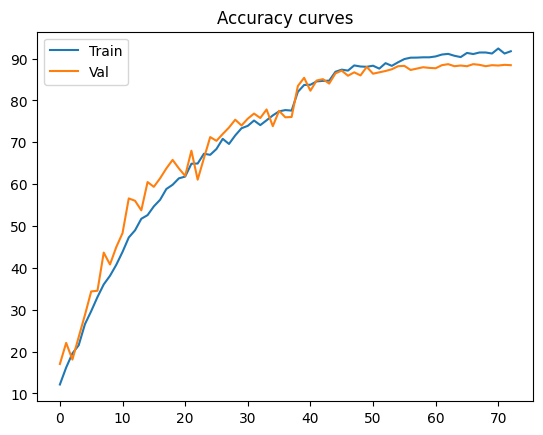

In [ ]:
num_epochs = 100
best_acc = 0
train_accs, val_accs = [], []

patience = 10  # Early Stopping limit
no_improve_epochs = 0  # counter for early stopping

for epoch in range(num_epochs):
    model.train()
    correct, total, running_loss = 0, 0, 0.0
    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        _, pred = torch.max(out, 1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    train_acc = 100 * correct / total

    # Validation phase
    model.eval()
    correct, total, val_loss = 0, 0, 0.0
    with torch.no_grad():
        for x, y in val_dl:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item() * x.size(0)
            _, pred = torch.max(out, 1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    val_acc = 100 * correct / total
    scheduler.step(val_acc)

    # Check for improvement
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_resnet34_oxford102.pth')
        no_improve_epochs = 0  # reset patience counter
    else:
        no_improve_epochs += 1

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Train acc: {train_acc:.2f}%  "
          f"Val acc: {val_acc:.2f}%  "
          f"Best: {best_acc:.2f}%")

    # Early stopping
    if no_improve_epochs >= patience:
        print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs).")
        break

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Val')
plt.legend()
plt.title('Accuracy curves')
plt.show()



1.   Stable convergence: The modelconverged smoothly without major fluctuations or overfitting.

2. Early stopping worked well: It prevented unnecessary training once the validation accuracy plateaued.

3. Saturation point: The plateau around 88–89% suggests potential architectural or data-related limits.

4. Future improvements: Further gains might come from data augmentation, hyperparameter tuning






In [ ]:
model.load_state_dict(torch.load('best_resnet34_oxford102.pth'))
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for x, y in test_dl:
        x, y = x.to(device), y.to(device)
        out = model(x)
        _, pred = torch.max(out, 1)
        correct += (pred == y).sum().item()
        total += y.size(0)
print(f"Test Accuracy: {100*correct/total:.2f}%")


Test Accuracy: 87.23%


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sn

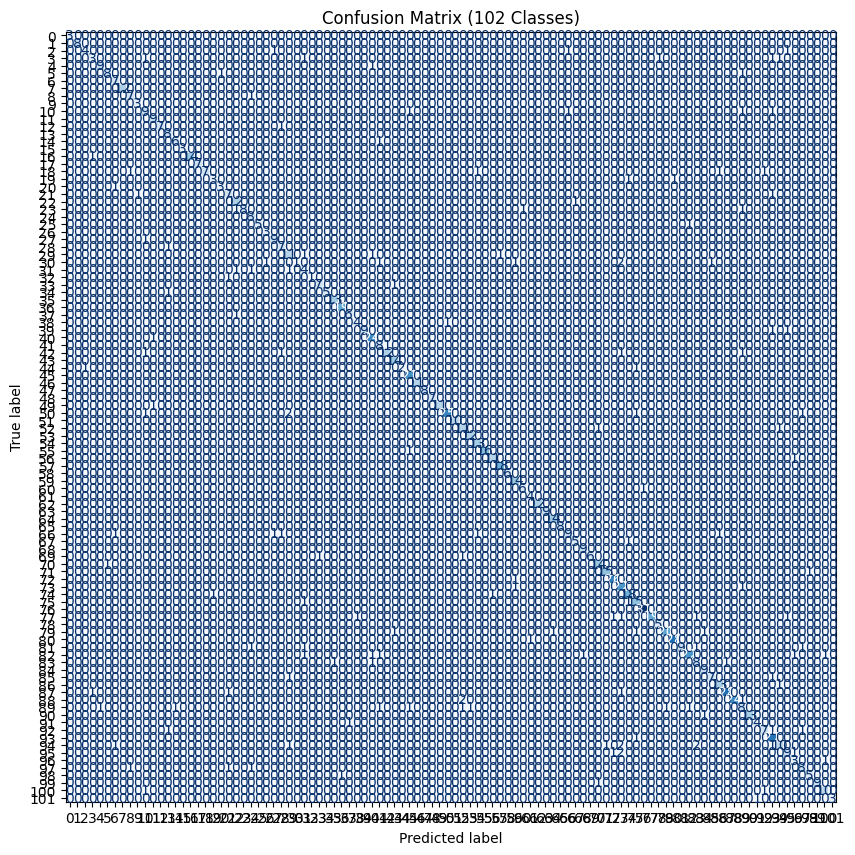

In [ ]:

model.load_state_dict(torch.load('a2_bonus_resnet_weights_rpandey3_tpatil3.pickle', map_location=device))
model.eval()

all_preds = []
all_labels = []


with torch.no_grad():
    for x, y in test_dl:
        x, y = x.to(device), y.to(device)
        out = model(x)
        _, pred = torch.max(out, 1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(y.cpu().numpy())


cm = confusion_matrix(all_labels, all_preds)
num_classes = len(np.unique(all_labels))


fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f"Confusion Matrix ({num_classes} Classes)")
plt.show()



1. The confusion matrix shows that the model performs well overall, with most predictions lying along the diagonal, indicating strong agreement between predicted and true labels.
2. Scalability Challenge:
With 102 classes, maintaining high precision and recall across all categories is inherently difficult.



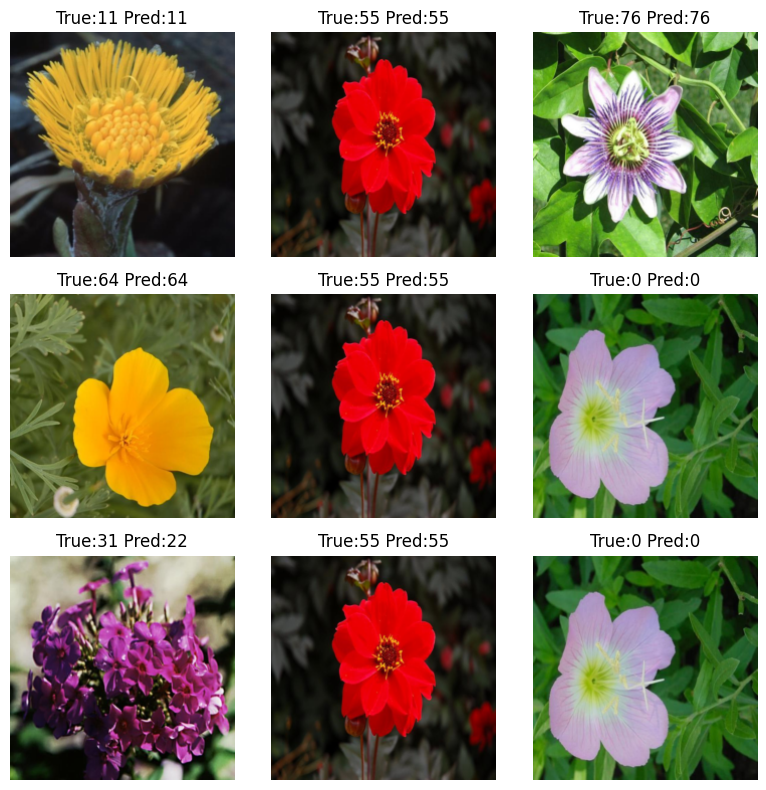

In [ ]:
import random
model.eval()
images, labels = next(iter(test_dl))
images, labels = images.to(device), labels.to(device)
out = model(images)
_, preds = torch.max(out, 1)

fig, axes = plt.subplots(3, 3, figsize=(8,8))
for i, ax in enumerate(axes.flat):
    idx = random.randint(0, len(images)-1)
    img = images[idx].cpu().permute(1,2,0) * torch.tensor(std) + torch.tensor(mean)
    img = torch.clamp(img, 0, 1)
    ax.imshow(img)
    ax.set_title(f"True:{labels[idx].item()} Pred:{preds[idx].item()}")
    ax.axis('off')
plt.tight_layout()




1.   Strong generalization: The majority of samples are correctly predicted, showing good learning across diverse flower categories.
2.   Visual consistency: Correct predictions show that the model generalizes well to natural lighting and complex backgrounds.



5. Save the trained model weights that return the best results (.pickle or .h5).

In [ ]:
model_save_path = 'resnet.pickle'


torch.save(model.state_dict(), model_save_path)

**Part 2:**
Model’s Interpretability

1. Convolutional layer outputs:
• Select at least three convolutional layers for visualization (e.g., early,
middle, and late layers).
• Extract the feature maps using hooks. Ideas
• Visualize the feature maps and analyze differences between layers.

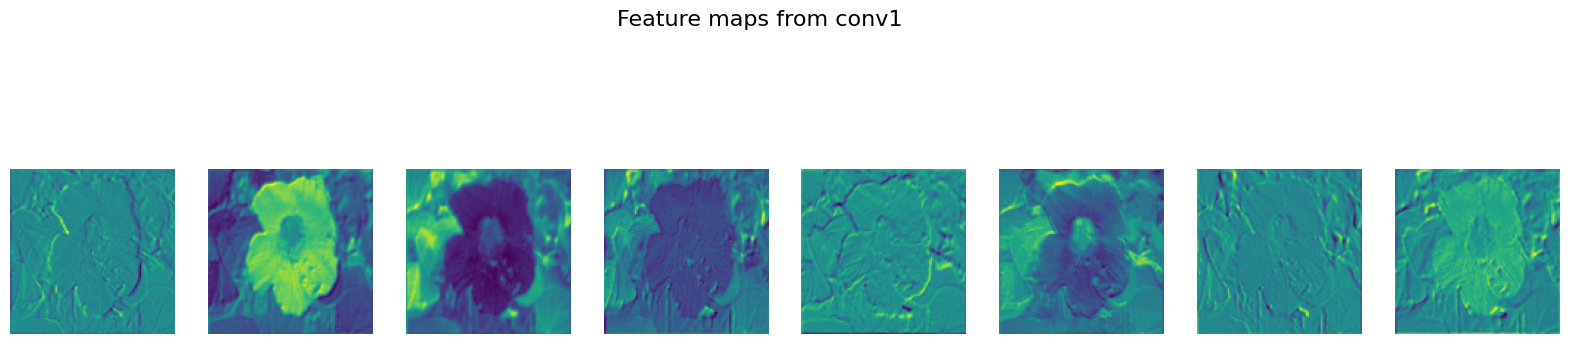

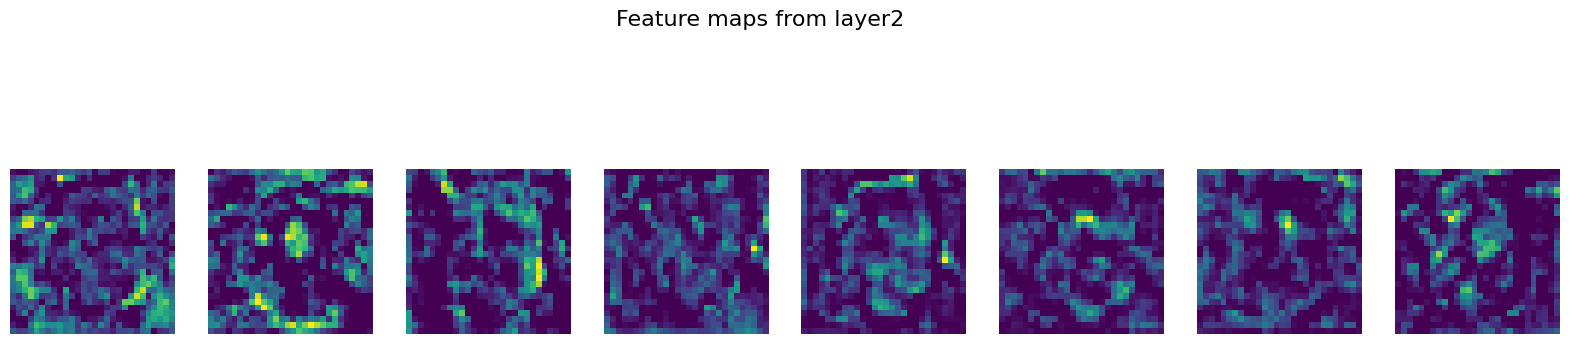

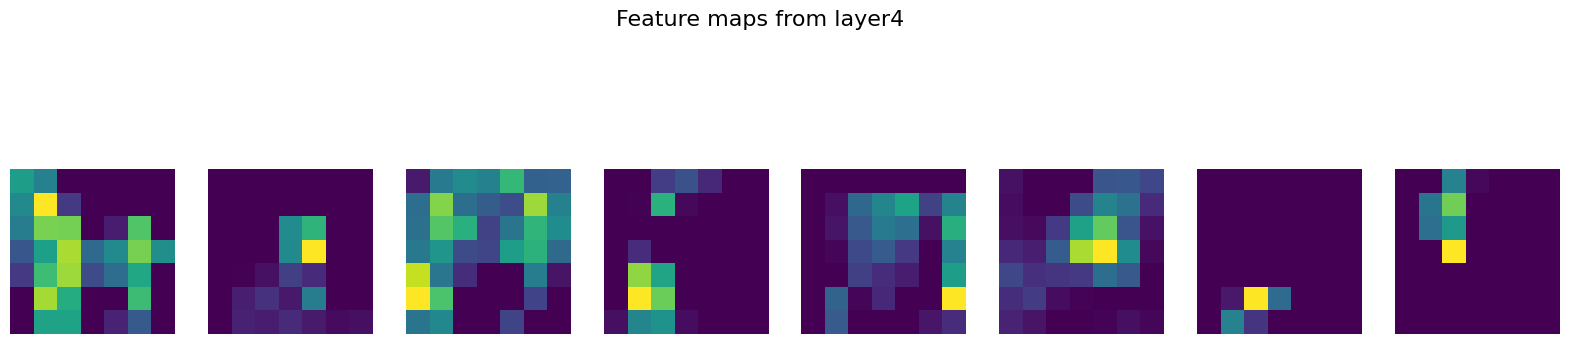

In [ ]:

model.load_state_dict(torch.load('resnet.pickle', map_location='cpu'))
model.eval()


model.to(device)


# layers (early, mid, late)
layer_names = ['conv1', 'layer2', 'layer4']
selected_layers = [model.conv1, model.layer2, model.layer4]


feature_maps = {}

# Hook function to store layer outputs
def get_activation(name):
    def hook(model, input, output):
        feature_maps[name] = output.detach()
    return hook

# Register hooks
hooks = []
for name, layer in zip(layer_names, selected_layers):
    hooks.append(layer.register_forward_hook(get_activation(name)))


from PIL import Image
from torchvision import transforms

tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

x, y = next(iter(test_dl))
x = x.to(device)
# Forward pass
with torch.no_grad():
    _ = model(x)

# Plot feature maps for each selected layer
for name in layer_names:
    fmap = feature_maps[name][0]  # first image in batch
    n_feat = min(8, fmap.shape[0])  # visualize first 8 feature maps
    fig, axes = plt.subplots(1, n_feat, figsize=(20, 5))
    for i in range(n_feat):
        axes[i].imshow(fmap[i].cpu(), cmap='viridis')
        axes[i].axis('off')
    fig.suptitle(f"Feature maps from {name}", fontsize=16)
    plt.show()

2. Activation layer outputs:
• Display the activation maps from selected layers after applying activation
functions (e.g., ReLU).
• Use hooks to capture the outputs after activation. Analyze how these
activations change with different inputs.
• Provide visualizations that illustrate which features are emphasized or
suppressed in the network. Discuss your observations.

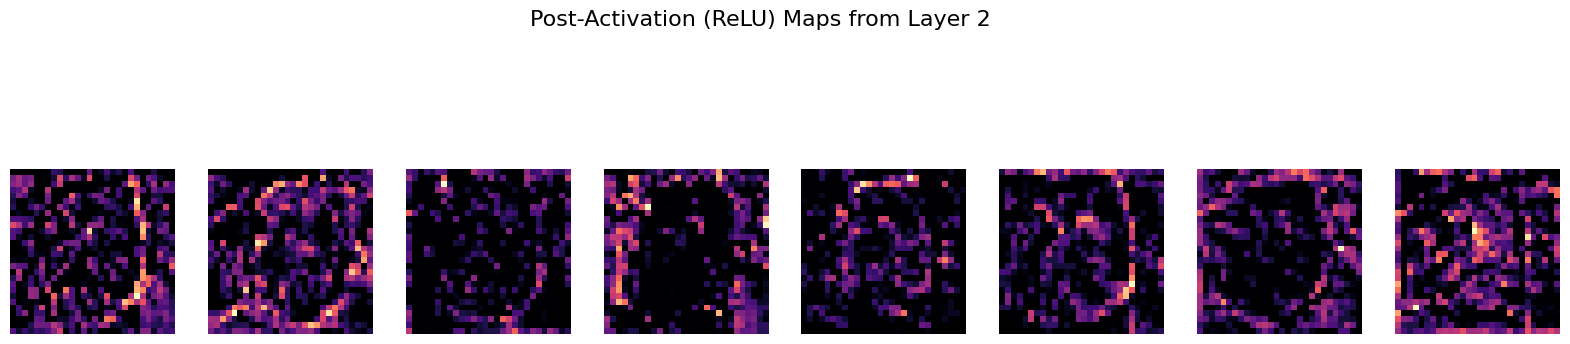

In [ ]:
activations = {}

def get_relu_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Register hook on ReLU layer
relu_hook = model.layer2[0].relu.register_forward_hook(get_relu_activation('layer2_relu'))

# Forward again
with torch.no_grad():
    _ = model(x)

# Visualize activation
act_map = activations['layer2_relu'][0]
fig, axes = plt.subplots(1, 8, figsize=(20, 5))
for i in range(8):
    axes[i].imshow(act_map[i].cpu(), cmap='magma')
    axes[i].axis('off')
plt.suptitle("Post-Activation (ReLU) Maps from Layer 2", fontsize=16)
plt.show()

relu_hook.remove()


3. Weight visualization:
• Extract and visualize the weights (kernels) from the early convolutional
layers
• Use model.conv1.weight.data to access the weights and visualize
• Discuss the types of features (e.g., edges, textures) that the network
learns from these weights

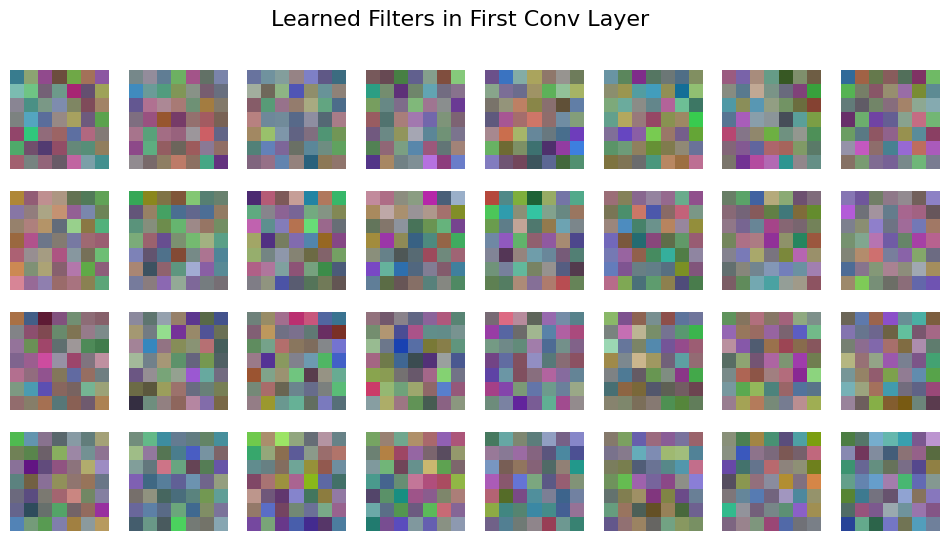

In [ ]:
weights = model.conv1.weight.data.clone()

# Normalize to [0,1] for visualization
w_min, w_max = weights.min(), weights.max()
weights = (weights - w_min) / (w_max - w_min)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i >= weights.shape[0]:
        break
    npimg = weights[i].permute(1, 2, 0).cpu().numpy()
    ax.imshow(npimg)
    ax.axis('off')
plt.suptitle("Learned Filters in First Conv Layer", fontsize=16)
plt.show()
